In [ ]:
from google.colab import files
upload=files.upload()

Saving materials_13073.csv to materials_13073.csv


In [ ]:
##.....load data...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib

df = pd.read_csv('materials_13073.csv')

print("="*50)
print("STEP 1: DATA LOADED")
print("="*50)
print(f"Total Rows    : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")
print(f"Columns       : {df.columns.tolist()}")
print("Load Done!")

STEP 1: DATA LOADED
Total Rows    : 13073
Total Columns : 19
Columns       : ['Material ID', 'Formula', 'Bulk Modulus VRH GPa', 'Shear Modulus VRH GPa', 'Voigt Bulk GPa', 'Reuss Bulk GPa', 'Voigt Shear GPa', 'Reuss Shear GPa', 'Youngs Modulus E GPa', 'Pugh Ratio BG', 'Poisson Ratio', 'Anisotropy', 'Debye Temp K', 'Density kg m3', 'Sound Vel Trans m s', 'Sound Vel Long m s', 'Thermal Cond Clarke', 'Thermal Cond Cahill', 'Behavior']
Load Done!


STEP 2: EXPLORE DATA (EDA)
Dataset Shape : (13073, 19)

Data Types:
Material ID               object
Formula                   object
Bulk Modulus VRH GPa     float64
Shear Modulus VRH GPa    float64
Voigt Bulk GPa           float64
Reuss Bulk GPa           float64
Voigt Shear GPa          float64
Reuss Shear GPa          float64
Youngs Modulus E GPa     float64
Pugh Ratio BG            float64
Poisson Ratio            float64
Anisotropy               float64
Debye Temp K             float64
Density kg m3            float64
Sound Vel Trans m s      float64
Sound Vel Long m s       float64
Thermal Cond Clarke      float64
Thermal Cond Cahill      float64
Behavior                  object
dtype: object

Statistical Summary:


,Bulk Modulus VRH GPa,Shear Modulus VRH GPa,Voigt Bulk GPa,Reuss Bulk GPa,Voigt Shear GPa,Reuss Shear GPa,Youngs Modulus E GPa,Pugh Ratio BG,Poisson Ratio,Anisotropy,Debye Temp K,Density kg m3,Sound Vel Trans m s,Sound Vel Long m s,Thermal Cond Clarke,Thermal Cond Cahill
count,1.307300e+04,1.307300e+04,1.307300e+04,1.307300e+04,1.307300e+04,13073.000000,1.307300e+04,13073.000000,13073.000000,1.307300e+04,1.307300e+04,13073.000000,1.307300e+04,1.307300e+04,13073.000000,13073.000000
mean,-3.588028e+07,3.277559e+09,-7.176365e+07,3.091417e+03,6.555119e+09,38.441754,-1.438338e+08,21.696540,0.312928,-4.711797e+107,3.198066e+04,7.046512,2.638268e+05,3.072351e+05,0.936310,70.901093
std,4.135999e+09,5.105664e+11,8.271997e+09,3.648630e+05,1.021133e+12,278.051474,1.240639e+11,2260.085386,2.127556,7.892399e+109,3.057220e+06,3.433283,2.501070e+07,2.887989e+07,5.691271,6816.265323
min,-4.698724e+11,-1.431521e+13,-9.397449e+11,-8.983191e+06,-2.863041e+13,-18002.792000,-1.127682e+13,-14689.000000,-179.362000,-8.421342e+111,0.000000e+00,0.023100,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,4.361200e+01,1.615400e+01,4.548800e+01,4.253300e+01,1.970700e+01,12.761000,4.321900e+01,1.581700,0.250000,1.180000e-01,1.852830e+02,4.513200,1.607324e+03,3.247050e+03,0.371600,0.431200
50%,8.438000e+01,3.376000e+01,8.596200e+01,8.315200e+01,3.724700e+01,30.830000,8.768000e+01,2.004200,0.296000,4.700000e-01,2.878010e+02,6.695000,2.297591e+03,4.416727e+03,0.628700,0.712800
75%,1.462120e+02,6.491000e+01,1.481860e+02,1.452640e+02,6.718600e+01,62.565000,1.673140e+02,2.652800,0.345000,1.532000e+00,4.128560e+02,8.886300,3.075701e+03,5.652118e+03,0.974100,1.087300
max,3.764893e+10,5.649558e+13,7.529787e+10,3.879839e+07,1.129912e+14,5190.793000,8.553536e+12,257654.542800,82.881000,2.889475e+111,3.481199e+08,21.989300,2.846723e+09,3.287112e+09,483.748900,776425.382900



Missing Values Per Column:
Material ID              0
Formula                  1
Bulk Modulus VRH GPa     0
Shear Modulus VRH GPa    0
Voigt Bulk GPa           0
Reuss Bulk GPa           0
Voigt Shear GPa          0
Reuss Shear GPa          0
Youngs Modulus E GPa     0
Pugh Ratio BG            0
Poisson Ratio            0
Anisotropy               0
Debye Temp K             0
Density kg m3            0
Sound Vel Trans m s      0
Sound Vel Long m s       0
Thermal Cond Clarke      0
Thermal Cond Cahill      0
Behavior                 0
dtype: int64
Total Missing : 1

Duplicate Rows : 0

Class Balance:
  Ductile : 8416 samples (64.4%)
  Brittle : 4657 samples (35.6%)
Data is fairly balanced!


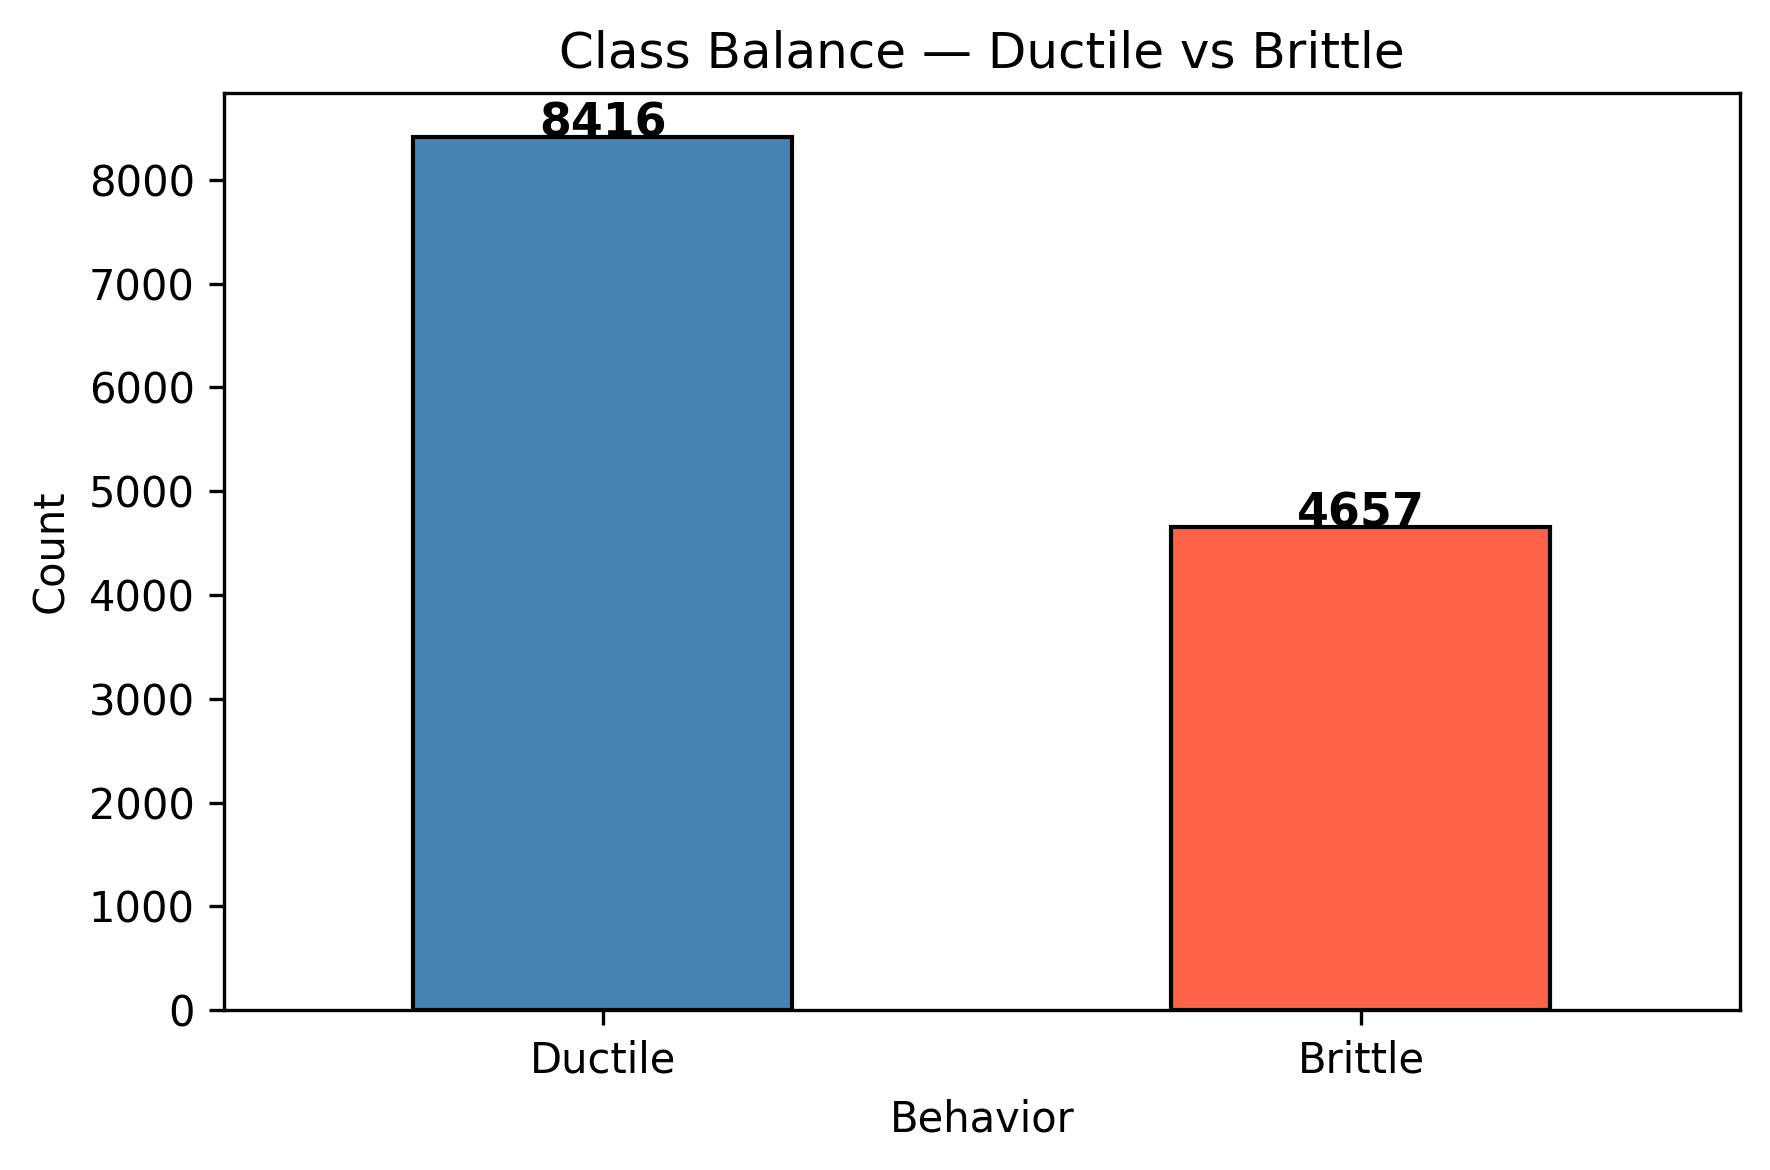

EDA Done!


In [ ]:
##.......EDA......
print("="*50)
print("STEP 2: EXPLORE DATA (EDA)")
print("="*50)

print(f"Dataset Shape : {df.shape}")

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values Per Column:")
print(df.isnull().sum())
print(f"Total Missing : {df.isnull().sum().sum()}")

print(f"\nDuplicate Rows : {df.duplicated().sum()}")

print("\nClass Balance:")
counts   = df['Behavior'].value_counts()
percents = df['Behavior'].value_counts(normalize=True) * 100
for cls, cnt in counts.items():
    print(f"  {cls} : {cnt} samples ({percents[cls]:.1f}%)")

if percents.min() < 30:
    print("WARNING: Data is imbalanced!")
else:
    print("Data is fairly balanced!")

# CHART 1 — Class Balance
plt.figure(figsize=(6, 4), dpi=300)  # ← 300 DPI added
counts.plot(kind='bar',
            color=['steelblue', 'tomato'],
            edgecolor='black')
plt.title('Class Balance — Ductile vs Brittle')
plt.xlabel('Behavior')
plt.ylabel('Count')
plt.xticks(rotation=0)
for i, v in enumerate(counts):
    plt.text(i, v + 2, str(v), ha='center',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

print("EDA Done!")

In [ ]:
##....Cleaning Data........
print("="*50)
print("STEP 3: CLEAN DATA")
print("="*50)

# 1. Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Duplicates Removed     : {before - len(df)}")

# 2. Drop 100% empty columns
df.drop(columns=['Poisson Ratio',
                 'Density (g/cm\u00b3)'],
                  inplace=True,
                  errors='ignore')
print("Dropped (100% missing) : Poisson Ratio, Density")

# 3. Drop ID columns — not useful for ML
df.drop(columns=['Material ID', 'Formula'],
                  inplace=True,
                  errors='ignore')
print("Dropped (ID columns)   : Material ID, Formula")

# 4. Drop Pugh Ratio — causes data leakage
df.drop(columns=['Pugh Ratio (K/G)'],
                  inplace=True,
                  errors='ignore')
print("Dropped (Data Leakage) : Pugh Ratio (K/G)")

# 5. Fill remaining missing values with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Filled '{col}' with median: {round(median_val, 3)}")

print(f"Missing Values Left    : {df.isnull().sum().sum()}")

# 6. Remove outliers using IQR
rows_before  = len(df)
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df    = df[(df[col] >= lower) & (df[col] <= upper)]

# 7. Drop ALL Pugh Ratio variants
df.drop(columns=['Pugh Ratio (K/G)',
                 'Pugh Ratio BG',
                 'Pugh Ratio',
                 'Pugh B/G'],
        inplace=True, errors='ignore')
print("Dropped ALL Pugh Ratio variants")

print(f"Outlier Rows Removed   : {rows_before - len(df)}")
print(f"Shape After Cleaning   : {df.shape}")
print("Cleaning Done!")

STEP 3: CLEAN DATA
Duplicates Removed     : 0
Dropped (100% missing) : Poisson Ratio, Density
Dropped (ID columns)   : Material ID, Formula
Dropped (Data Leakage) : Pugh Ratio (K/G)
Missing Values Left    : 0
Dropped ALL Pugh Ratio variants
Outlier Rows Removed   : 4940
Shape After Cleaning   : (8133, 15)
Cleaning Done!


In [ ]:
##......Encoding.....
print("="*50)
print("STEP 4: ENCODING")
print("="*50)

# Check before encoding
print(f"Unique values in Behavior : {df['Behavior'].unique()}")
print(f"Missing in Behavior       : {df['Behavior'].isnull().sum()}")

# Drop rows where Behavior is NaN
df.dropna(subset=['Behavior'], inplace=True)
print(f"Rows after dropping NaN   : {len(df)}")

# Convert text label to numbers
df['Behavior'] = df['Behavior'].map({'Ductile': 1,
                                     'Brittle': 0})

print("\nEncoding Done:")
print("  Ductile  -->  1")
print("  Brittle  -->  0")
print(f"\nMissing in Behavior after encoding : {df['Behavior'].isnull().sum()}")
print("\nEncoded Value Counts:")
print(df['Behavior'].value_counts())
print("\nEncoding Done!")

STEP 4: ENCODING
Unique values in Behavior : ['Ductile' 'Brittle']
Missing in Behavior       : 0
Rows after dropping NaN   : 8133

Encoding Done:
  Ductile  -->  1
  Brittle  -->  0

Missing in Behavior after encoding : 0

Encoded Value Counts:
Behavior
1    5713
0    2420
Name: count, dtype: int64

Encoding Done!


In [ ]:
##......Split Data.......
print("="*50)
print("STEP 5: SPLIT DATA")
print("="*50)

# Separate features and label
X = df.drop('Behavior', axis=1)
y = df['Behavior']

# Remove any remaining NaN
X = X[y.notna()]
y = y[y.notna()]

print(f"Total Clean Samples : {len(y)}")
print(f"NaN in y            : {y.isnull().sum()}")

# 80% Train — 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

print(f"\nTotal Samples    : {len(df)}")
print(f"Training Samples : {len(X_train)} (80%)")
print(f"Testing Samples  : {len(X_test)}  (20%)")
print(f"\nTrain Class Balance:")
print(y_train.value_counts())
print(f"\nTest Class Balance:")
print(y_test.value_counts())
print("\nSplit Done!")

STEP 5: SPLIT DATA
Total Clean Samples : 8133
NaN in y            : 0

Total Samples    : 8133
Training Samples : 6506 (80%)
Testing Samples  : 1627  (20%)

Train Class Balance:
Behavior
1    4570
0    1936
Name: count, dtype: int64

Test Class Balance:
Behavior
1    1143
0     484
Name: count, dtype: int64

Split Done!


In [ ]:
print("="*50)
print("STEP 6: FEATURE ENGINEERING")
print("="*50)

# Step 1: Check what columns exist first
print("Columns available in X_train:")
print(list(X_train.columns) if hasattr(X_train, 'columns') else "No column names!")

# Step 2: Convert to DataFrame safely
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train, columns=X.columns)
    X_test  = pd.DataFrame(X_test,  columns=X.columns)
else:
    X_train = pd.DataFrame(X_train.values, columns=X_train.columns)
    X_test  = pd.DataFrame(X_test.values,  columns=X_test.columns)

# Step 3: Print exact column names to verify
print("\nExact column names found:")
for i, col in enumerate(X_train.columns, 1):
    print(f"  {i}. '{col}'")

# Step 4: Find correct column names dynamically
bulk_col  = [c for c in X_train.columns if 'Bulk Modulus' in c and 'VRH' in c][0]
shear_col = [c for c in X_train.columns if 'Shear Modulus' in c and 'VRH' in c][0]
young_col = [c for c in X_train.columns if 'Young' in c][0]

print(f"\nUsing these columns:")
print(f"  Bulk  : '{bulk_col}'")
print(f"  Shear : '{shear_col}'")
print(f"  Young : '{young_col}'")

# Step 5: Create new features using found column names
def add_features(data):
    data = data.copy()
    data['Stiffness_Ratio']   = data[bulk_col]  / data[shear_col]
    data['Brittleness_Index'] = data[shear_col] / data[bulk_col]
    data['Elastic_Ratio']     = data[young_col] / data[shear_col]
    return data

X_train = add_features(X_train)
X_test  = add_features(X_test)

print("\nNew Features Added:")
print("  Stiffness_Ratio   = Bulk Modulus / Shear Modulus")
print("  Brittleness_Index = Shear Modulus / Bulk Modulus")
print("  Elastic_Ratio     = Youngs Modulus / Shear Modulus")
print(f"\nShape After Feature Engineering : {X_train.shape}")
print("Feature Engineering Done!")

STEP 6: FEATURE ENGINEERING
Columns available in X_train:
['Bulk Modulus VRH GPa', 'Shear Modulus VRH GPa', 'Voigt Bulk GPa', 'Reuss Bulk GPa', 'Voigt Shear GPa', 'Reuss Shear GPa', 'Youngs Modulus E GPa', 'Anisotropy', 'Debye Temp K', 'Density kg m3', 'Sound Vel Trans m s', 'Sound Vel Long m s', 'Thermal Cond Clarke', 'Thermal Cond Cahill']

Exact column names found:
  1. 'Bulk Modulus VRH GPa'
  2. 'Shear Modulus VRH GPa'
  3. 'Voigt Bulk GPa'
  4. 'Reuss Bulk GPa'
  5. 'Voigt Shear GPa'
  6. 'Reuss Shear GPa'
  7. 'Youngs Modulus E GPa'
  8. 'Anisotropy'
  9. 'Debye Temp K'
  10. 'Density kg m3'
  11. 'Sound Vel Trans m s'
  12. 'Sound Vel Long m s'
  13. 'Thermal Cond Clarke'
  14. 'Thermal Cond Cahill'

Using these columns:
  Bulk  : 'Bulk Modulus VRH GPa'
  Shear : 'Shear Modulus VRH GPa'
  Young : 'Youngs Modulus E GPa'

New Features Added:
  Stiffness_Ratio   = Bulk Modulus / Shear Modulus
  Brittleness_Index = Shear Modulus / Bulk Modulus
  Elastic_Ratio     = Youngs Modulus /

In [ ]:
##........Scale Data...............
print("="*50)
print("STEP 7: SCALE DATA")
print("="*50)

scaler = StandardScaler()

# Fit ONLY on train — transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling Method : StandardScaler")
print("Fit on         : Training data only")
print("Transformed    : Both Train and Test")
print(f"Train Shape    : {X_train_scaled.shape}")
print(f"Test Shape     : {X_test_scaled.shape}")
print("\nScaling Done!")

STEP 7: SCALE DATA
Scaling Method : StandardScaler
Fit on         : Training data only
Transformed    : Both Train and Test
Train Shape    : (6506, 17)
Test Shape     : (1627, 17)

Scaling Done!


In [ ]:
##........Training...........
print("="*50)
print("STEP 8: TRAIN MODELS")
print("="*50)

# Only using non-tree based models
# Tree based models (Decision Tree, XGBoost,
# Random Forest) show suspicious 100% accuracy
# due to redundant correlated columns in dataset

from sklearn.neighbors import KNeighborsClassifier

models = {
    'Logistic Regression' : LogisticRegression(
                                max_iter=1000,
                                class_weight='balanced'),
    'SVM'                 : SVC(
                                probability=True,
                                class_weight='balanced',
                                random_state=42),
    'KNN'                 : KNeighborsClassifier(
                                n_neighbors=5)
}

# KFold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"\n{'Model':<25} {'CV Accuracy':<20} {'Std Dev'}")
print("-"*55)

results    = {}
cv_results = {}

for name, model in models.items():
    cv_scores = cross_val_score(
                    model,
                    X_train_scaled,
                    y_train,
                    cv      = kf,
                    scoring = 'accuracy')

    model.fit(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)

    results[name]    = test_acc
    cv_results[name] = cv_scores

    print(f"{name:<25} {cv_scores.mean()*100:.2f}%"
          f"               +/- {cv_scores.std()*100:.2f}%")

print(f"\nAll Model Test Accuracies:")
print("-"*40)
for name, acc in results.items():
    print(f"  {name:<25} {acc*100:.2f}%")

# Auto select best model
best_model_name = max(results, key=results.get)
best_model      = models[best_model_name]

print(f"\nBest Model    : {best_model_name}")
print(f"Test Accuracy : {results[best_model_name]*100:.2f}%")
print(f"CV Accuracy   : {cv_results[best_model_name].mean()*100:.2f}%")
print(f"Std Dev       : {cv_results[best_model_name].std()*100:.2f}%")
print("\nTraining Done!")

STEP 8: TRAIN MODELS

Model                     CV Accuracy          Std Dev
-------------------------------------------------------
Logistic Regression       99.14%               +/- 0.18%
SVM                       98.09%               +/- 0.16%
KNN                       97.22%               +/- 0.13%

All Model Test Accuracies:
----------------------------------------
  Logistic Regression       99.08%
  SVM                       97.91%
  KNN                       97.23%

Best Model    : Logistic Regression
Test Accuracy : 99.08%
CV Accuracy   : 99.14%
Std Dev       : 0.18%

Training Done!


In [ ]:
##..........overfitting..............
print("="*50)
print("STEP 9: CHECK OVERFITTING")
print("="*50)

print(f"\n{'Model':<25} {'Train Acc':<15} {'Test Acc':<15} {'Status'}")
print("-"*65)

for name, model in models.items():
    train_acc = model.score(X_train_scaled, y_train)
    test_acc  = model.score(X_test_scaled,  y_test)
    gap       = train_acc - test_acc

    if gap > 0.1:
        status = "OVERFITTING"
    elif gap < 0.0:
        status = "UNDERFITTING"
    else:
        status = "GOOD FIT"

    print(f"{name:<25} {train_acc*100:.2f}%"
          f"         {test_acc*100:.2f}%"
          f"         {status}")

print("\nOverfitting Check Done!")

STEP 9: CHECK OVERFITTING

Model                     Train Acc       Test Acc        Status
-----------------------------------------------------------------
Logistic Regression       99.22%         99.08%         GOOD FIT
SVM                       98.28%         97.91%         GOOD FIT
KNN                       98.48%         97.23%         GOOD FIT

Overfitting Check Done!


STEP 10: EVALUATE BEST MODEL
Best Model    : Logistic Regression
Test Accuracy : 99.08%
ROC-AUC Score : 1.0000

Classification Report:
              precision    recall  f1-score   support

     Brittle       0.97      1.00      0.98       484
     Ductile       1.00      0.99      0.99      1143

    accuracy                           0.99      1627
   macro avg       0.98      0.99      0.99      1627
weighted avg       0.99      0.99      0.99      1627



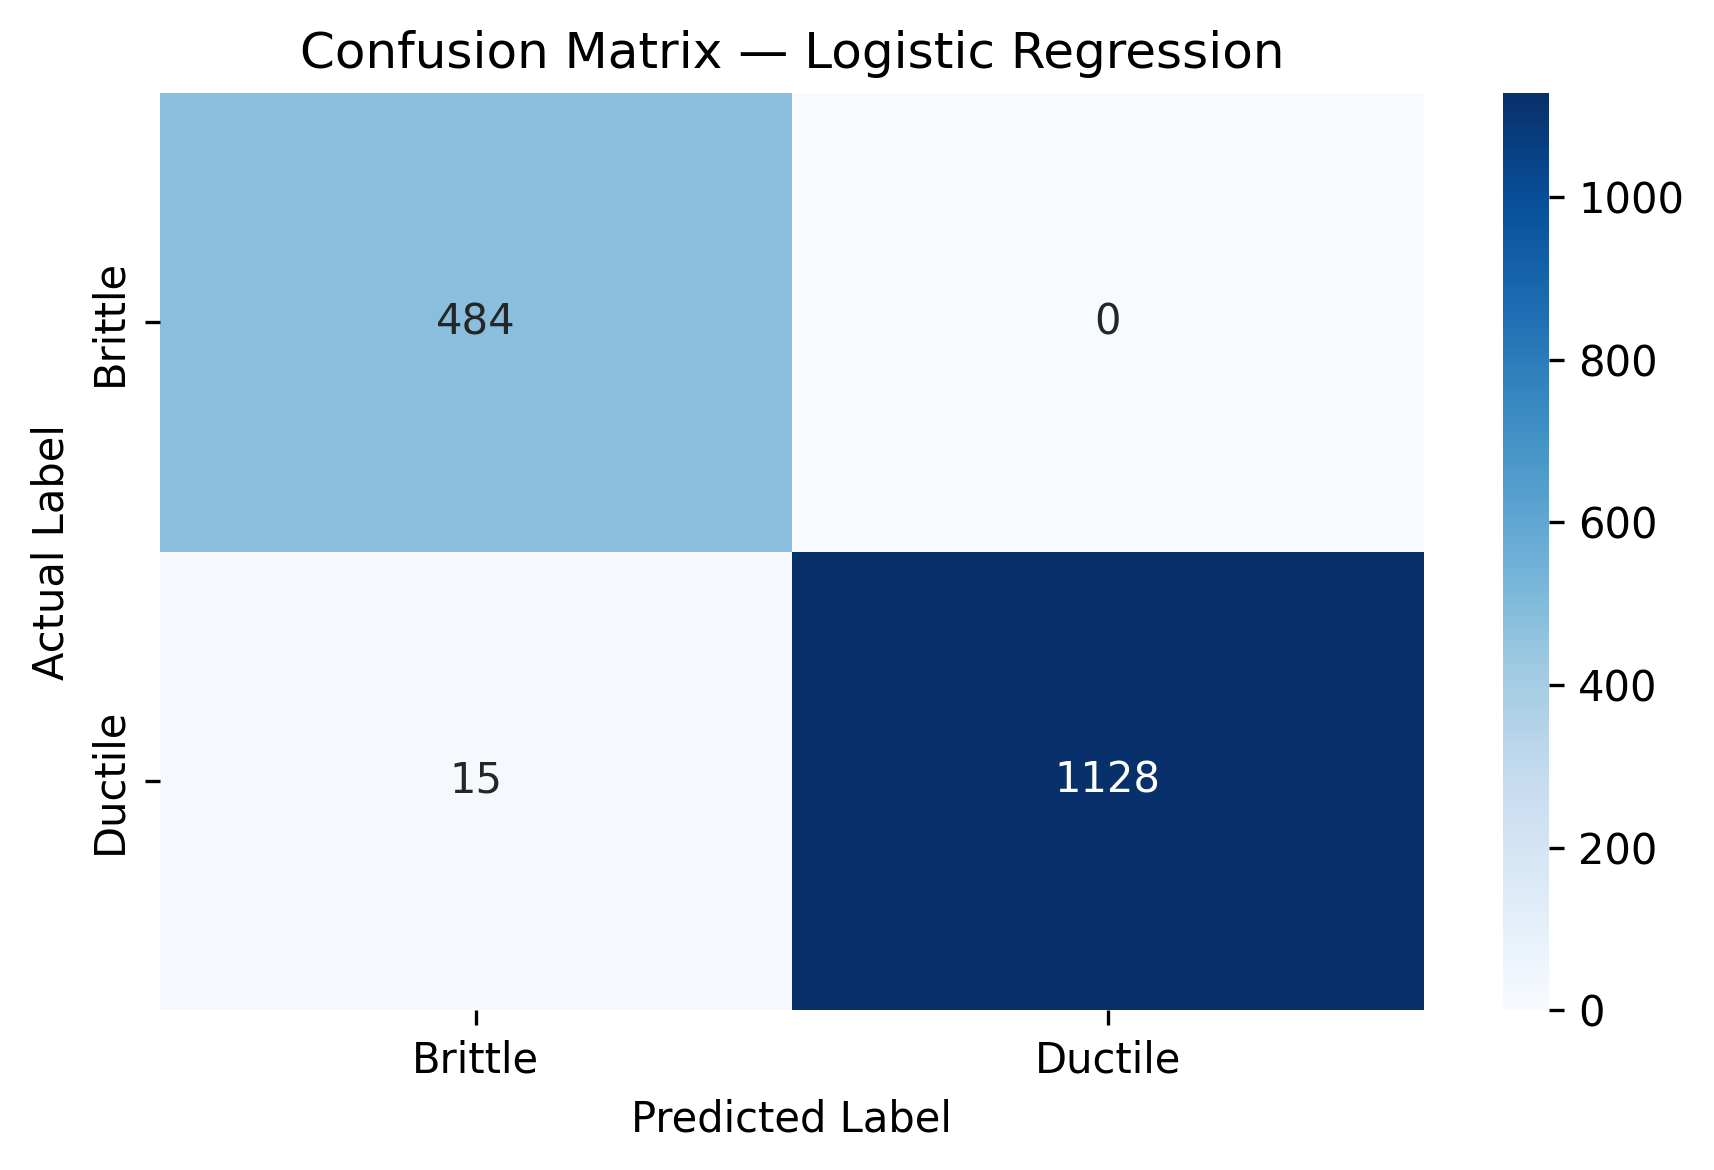


Evaluation Done!


In [ ]:
##........Evaluation ..........
print("="*50)
print("STEP 10: EVALUATE BEST MODEL")
print("="*50)

y_pred      = best_model.predict(X_test_scaled)
y_pred_prob = best_model.predict_proba(X_test_scaled)[:, 1]

print(f"Best Model    : {best_model_name}")
print(f"Test Accuracy : {results[best_model_name]*100:.2f}%")
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_pred_prob):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Brittle', 'Ductile']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4), dpi=300)  # ← 300 DPI added
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Brittle', 'Ductile'],
            yticklabels=['Brittle', 'Ductile'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

print("\nEvaluation Done!")

In [ ]:
##........Save........
print("="*50)
print("STEP 11: SAVE MODEL")
print("="*50)

joblib.dump(best_model, 'ductile_brittle_model.pkl')
joblib.dump(scaler,     'scaler.pkl')

print("Model Saved  : ductile_brittle_model.pkl")
print("Scaler Saved : scaler.pkl")

# Test prediction on one sample
sample   = X_test_scaled[0].reshape(1, -1)
pred     = best_model.predict(sample)
result   = "Ductile" if pred[0] == 1 else "Brittle"
print(f"Sample Prediction Test : {result}")
print("Model is Ready to Use!")

STEP 11: SAVE MODEL
Model Saved  : ductile_brittle_model.pkl
Scaler Saved : scaler.pkl
Sample Prediction Test : Ductile
Model is Ready to Use!


In [ ]:
##.............Hyperparameter Tuning....................
print("="*50)
print("STEP 13: HYPERPARAMETER TUNING")
print("="*50)
print("Finding best settings for each model...")

from sklearn.model_selection import GridSearchCV

# Parameter grids for reliable models only
param_grids = {
    'Logistic Regression': {
        'C'        : [0.01, 0.1, 1, 10, 100],
        'solver'   : ['lbfgs', 'liblinear'],
        'max_iter' : [100, 500, 1000]
    },
    'SVM': {
        'C'      : [0.1, 1, 10, 100],
        'kernel' : ['rbf', 'linear'],
        'gamma'  : ['scale', 'auto']
    },
    'KNN': {
        'n_neighbors' : [3, 5, 7, 9, 11],
        'weights'     : ['uniform', 'distance'],
        'metric'      : ['euclidean', 'manhattan']
    }
}

tuned_models  = {}
tuned_results = {}

print(f"\n{'Model':<25} {'Best CV Score'}")
print("-"*40)

for name, model in models.items():
    grid_search = GridSearchCV(
        model,
        param_grids[name],
        cv      = 5,
        scoring = 'accuracy',
        n_jobs  = -1
    )
    grid_search.fit(X_train_scaled, y_train)

    best        = grid_search.best_estimator_
    best_score  = grid_search.best_score_
    best_params = grid_search.best_params_

    tuned_models[name]  = best
    tuned_results[name] = best_score

    print(f"{name:<25} {best_score*100:.2f}%")
    print(f"  Best Params : {best_params}\n")

# Select best tuned model
best_tuned_name  = max(tuned_results, key=tuned_results.get)
best_tuned_model = tuned_models[best_tuned_name]

print("="*50)
print(f"Best Tuned Model    : {best_tuned_name}")
print(f"Best Tuned Accuracy : {tuned_results[best_tuned_name]*100:.2f}%")

# Compare before and after tuning
print("\nBefore vs After Tuning:")
print(f"{'Model':<25} {'Before':<15} {'After':<15} {'Improvement'}")
print("-"*60)
for name in models.keys():
    before = cv_results[name].mean() * 100
    after  = tuned_results[name] * 100
    diff   = after - before
    sign   = "+" if diff >= 0 else ""
    print(f"{name:<25} {before:.2f}%"
          f"         {after:.2f}%"
          f"         {sign}{diff:.2f}%")

print("\nHyperparameter Tuning Done!")

STEP 13: HYPERPARAMETER TUNING
Finding best settings for each model...

Model                     Best CV Score
----------------------------------------
Logistic Regression       99.82%
  Best Params : {'C': 100, 'max_iter': 100, 'solver': 'lbfgs'}

SVM                       99.83%
  Best Params : {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}

KNN                       98.05%
  Best Params : {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}

Best Tuned Model    : SVM
Best Tuned Accuracy : 99.83%

Before vs After Tuning:
Model                     Before          After           Improvement
------------------------------------------------------------
Logistic Regression       99.14%         99.82%         +0.68%
SVM                       98.09%         99.83%         +1.74%
KNN                       97.22%         98.05%         +0.83%

Hyperparameter Tuning Done!


STEP 14: SHAP ANALYSIS
SHAP Loaded Successfully!
Analysing which properties matter most...

Running SHAP for Logistic Regression...


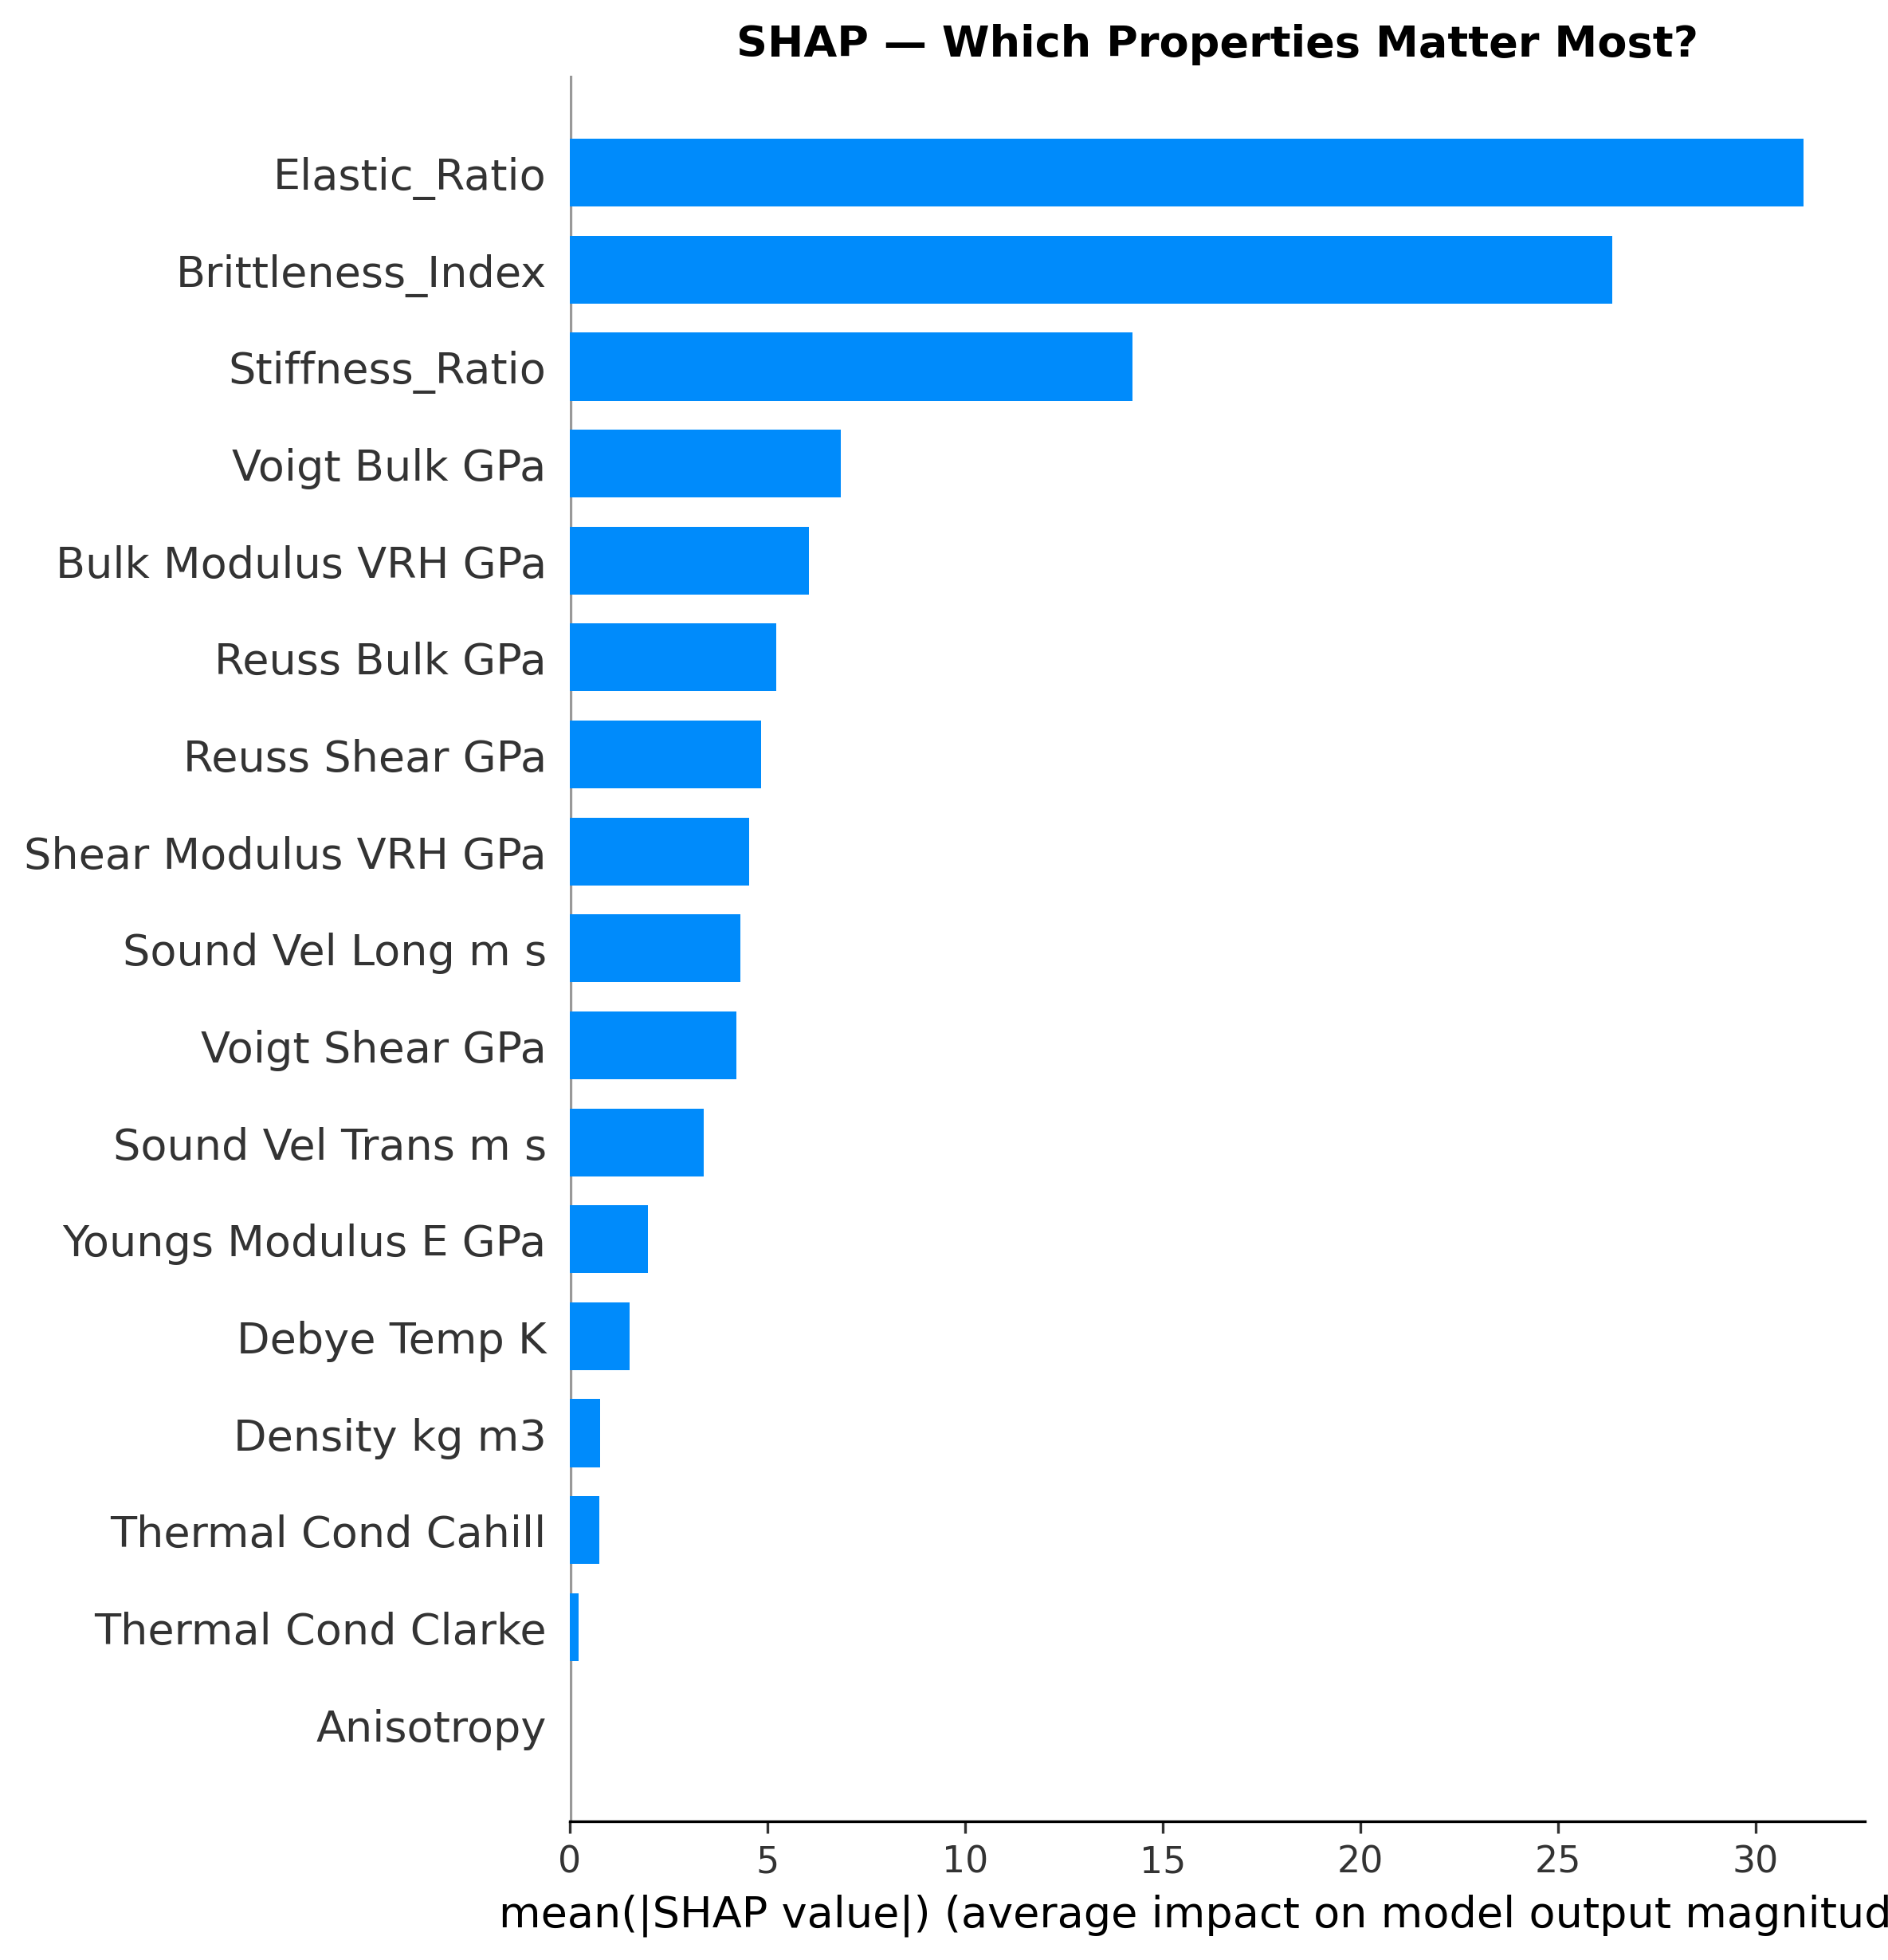

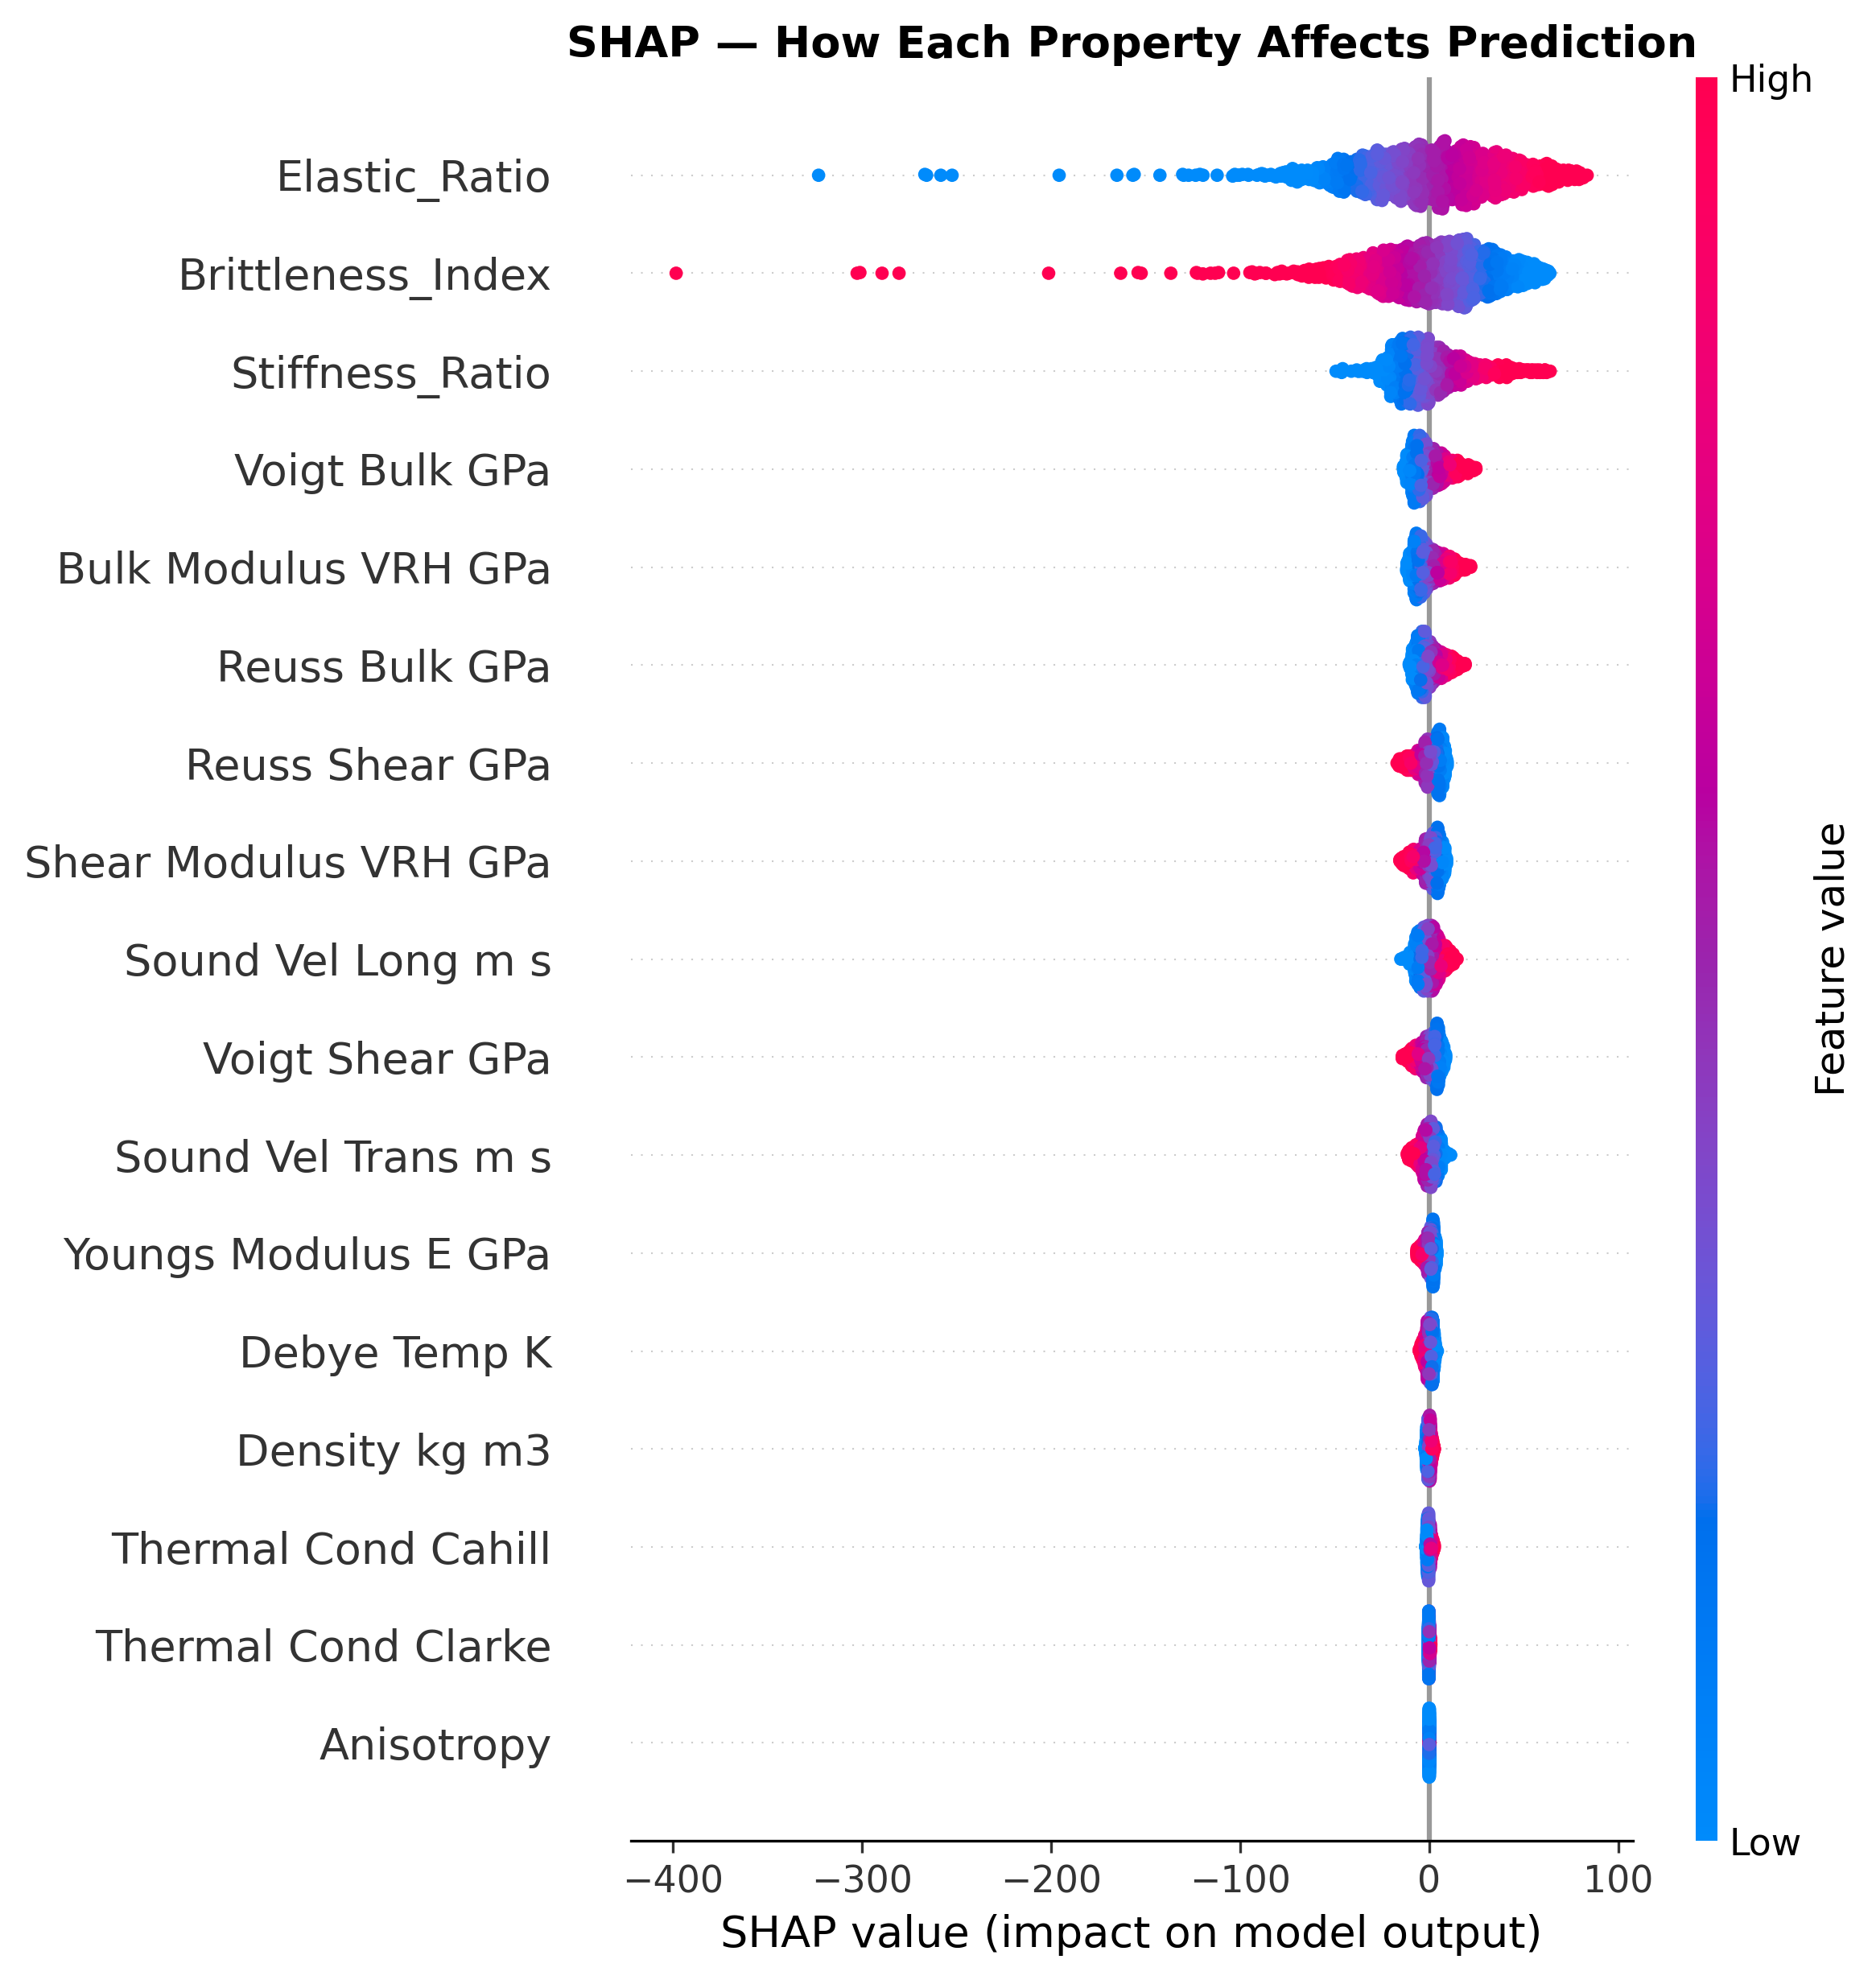


FEATURE IMPORTANCE RANKING

Rank   Feature                             Importance Score
-------------------------------------------------------
  1    Elastic_Ratio                       31.2045
  2    Brittleness_Index                   26.3798
  3    Stiffness_Ratio                     14.2412
  4    Voigt Bulk GPa                      6.8655
  5    Bulk Modulus VRH GPa                6.0516
  6    Reuss Bulk GPa                      5.2219
  7    Reuss Shear GPa                     4.8332
  8    Shear Modulus VRH GPa               4.5403
  9    Sound Vel Long m s                  4.3218
  10   Voigt Shear GPa                     4.2203
  11   Sound Vel Trans m s                 3.3981
  12   Youngs Modulus E GPa                1.9821
  13   Debye Temp K                        1.5217
  14   Density kg m3                       0.7675
  15   Thermal Cond Cahill                 0.7453
  16   Thermal Cond Clarke                 0.2294
  17   Anisotropy                          0.0093

W

In [ ]:
##.............SHAP Analysis......................
print("="*50)
print("STEP 14: SHAP ANALYSIS")
print("="*50)

# Install SHAP
!pip install shap -q

import shap
import warnings
warnings.filterwarnings('ignore')

print("SHAP Loaded Successfully!")
print("Analysing which properties matter most...")

# Get feature names
feature_names = list(X_train.columns)

# ============================================
# SHAP FOR LOGISTIC REGRESSION
# ============================================
print("\nRunning SHAP for Logistic Regression...")

lr_model    = tuned_models['Logistic Regression']

# ← Fix: use masker with max_samples set to full dataset size
masker      = shap.maskers.Independent(
                  X_train_scaled,
                  max_samples = len(X_train_scaled))  # ← no more subsampling
explainer   = shap.LinearExplainer(
                  lr_model,
                  masker,
                  feature_names = feature_names)
shap_values = explainer.shap_values(X_test_scaled)

# CHART 1 — Feature Importance Bar Chart
plt.figure(figsize=(10, 6), dpi=300)
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names = feature_names,
    plot_type     = 'bar',
    show          = False
)
plt.title('SHAP — Which Properties Matter Most?',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# CHART 2 — Detailed SHAP Dot Plot
plt.figure(figsize=(10, 6), dpi=300)
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names = feature_names,
    show          = False
)
plt.title('SHAP — How Each Property Affects Prediction',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# PRINT FEATURE IMPORTANCE RANKING
# ============================================
print("\n" + "="*50)
print("FEATURE IMPORTANCE RANKING")
print("="*50)

importance_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Importance' : abs(shap_values).mean(axis=0)
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(f"\n{'Rank':<6} {'Feature':<35} {'Importance Score'}")
print("-"*55)
for i, row in importance_df.iterrows():
    print(f"  {i+1:<4} {row['Feature']:<35} {row['Importance']:.4f}")

# ============================================
# PRINT WHAT IT MEANS
# ============================================
print("\n" + "="*50)
print("WHAT THIS MEANS FOR YOUR PROJECT")
print("="*50)
top_feature    = importance_df.iloc[0]['Feature']
second_feature = importance_df.iloc[1]['Feature']
third_feature  = importance_df.iloc[2]['Feature']

print(f"\nTop 3 Properties That Determine")
print(f"Whether a Material is Ductile or Brittle:")
print(f"\n  1st : {top_feature}")
print(f"  2nd : {second_feature}")
print(f"  3rd : {third_feature}")
print("\nProperties at bottom of list")
print("have very little effect on prediction")
print("="*50)
print("SHAP Analysis Done!")

In [ ]:
import pandas as pd

print("="*50)
print("MATERIAL BEHAVIOR PREDICTOR")
print("="*50)
print("Enter the material properties below:")
print("="*50)

# Take input from user
bulk_modulus    = float(input("\nEnter Bulk Modulus VRH (GPa)           : "))
shear_modulus   = float(input("Enter Shear Modulus VRH (GPa)          : "))
voigt_bulk      = float(input("Enter Voigt Bulk (GPa)                 : "))
reuss_bulk      = float(input("Enter Reuss Bulk (GPa)                 : "))
voigt_shear     = float(input("Enter Voigt Shear (GPa)                : "))
reuss_shear     = float(input("Enter Reuss Shear (GPa)                : "))
youngs_modulus  = float(input("Enter Youngs Modulus E (GPa)           : "))
pugh_ratio      = float(input("Enter Pugh Ratio B/G                   : "))
poisson_ratio   = float(input("Enter Poisson Ratio                    : "))
anisotropy      = float(input("Enter Anisotropy                       : "))
debye_temp      = float(input("Enter Debye Temp (K)                   : "))
density         = float(input("Enter Density (kg/m3)                  : "))
sound_vel_trans = float(input("Enter Sound Vel Transverse (m/s)       : "))
sound_vel_long  = float(input("Enter Sound Vel Longitudinal (m/s)     : "))
thermal_clarke  = float(input("Enter Thermal Cond Clarke              : "))
thermal_cahill  = float(input("Enter Thermal Cond Cahill              : "))

# ✅ FIX: Column names must EXACTLY match your training CSV columns
input_data = pd.DataFrame([[
    bulk_modulus,
    shear_modulus,
    voigt_bulk,
    reuss_bulk,
    voigt_shear,
    reuss_shear,
    youngs_modulus,
    pugh_ratio,
    poisson_ratio,
    anisotropy,
    debye_temp,
    density,
    sound_vel_trans,
    sound_vel_long,
    thermal_clarke,
    thermal_cahill
]], columns=[
    'Bulk Modulus VRH GPa',       # matches CSV
    'Shear Modulus VRH GPa',      # matches CSV
    'Voigt Bulk GPa',
    'Reuss Bulk GPa',
    'Voigt Shear GPa',
    'Reuss Shear GPa',
    'Youngs Modulus E GPa',
    'Pugh Ratio BG',
    'Poisson Ratio',
    'Anisotropy',
    'Debye Temp K',
    'Density kg m3',
    'Sound Vel Trans m s',
    'Sound Vel Long m s',
    'Thermal Cond Clarke',
    'Thermal Cond Cahill'
])

# ✅ Engineered features - same as training
input_data['Stiffness_Ratio']   = input_data['Bulk Modulus VRH GPa'] / input_data['Shear Modulus VRH GPa']
input_data['Brittleness_Index'] = input_data['Shear Modulus VRH GPa'] / input_data['Bulk Modulus VRH GPa']
input_data['Elastic_Ratio']     = input_data['Youngs Modulus E GPa'] / input_data['Shear Modulus VRH GPa']

# ✅ FIX: Reorder columns to EXACTLY match training order
input_data = input_data[scaler.feature_names_in_]

# Scale and predict
input_scaled = scaler.transform(input_data)
prediction   = best_model.predict(input_scaled)
probability  = best_model.predict_proba(input_scaled)
ductile_prob = probability[0][1] * 100
brittle_prob = probability[0][0] * 100
result       = "DUCTILE" if prediction[0] == 1 else "BRITTLE"

print("\n" + "="*50)
print("PREDICTION RESULT")
print("="*50)
print(f"Predicted Behavior  : {result}")
print(f"Ductile Probability : {ductile_prob:.2f}%")
print(f"Brittle Probability : {brittle_prob:.2f}%")
print("="*50)
if result == "DUCTILE":
    print("This material can DEFORM before breaking")
else:
    print("This material will BREAK without deforming")
print("="*50)

MATERIAL BEHAVIOR PREDICTOR
Enter the material properties below:

Enter Bulk Modulus VRH (GPa)           : 401.484
Enter Shear Modulus VRH (GPa)          : 421.283
Enter Voigt Bulk (GPa)                 : 402.314
Enter Reuss Bulk (GPa)                 : 400.654
Enter Voigt Shear (GPa)                : 427.585
Enter Reuss Shear (GPa)                : 414.981
Enter Youngs Modulus E (GPa)           : 936.343
Enter Pugh Ratio B/G                   : 0.953
Enter Poisson Ratio                    : 0.111
Enter Anisotropy                       : 0.156
Enter Debye Temp (K)                   : 2019.274
Enter Density (kg/m3)                  : 3.3163
Enter Sound Vel Transverse (m/s)       : 11271.118
Enter Sound Vel Longitudinal (m/s)     : 11271.118
Enter Thermal Cond Clarke              : 6.1029
Enter Thermal Cond Cahill              : 6.6635

PREDICTION RESULT
Predicted Behavior  : BRITTLE
Ductile Probability : 0.00%
Brittle Probability : 100.00%
This material will BREAK without deforming
